Bagging in Machine Learning (Interview Short Note)

Bagging (Bootstrap Aggregating) is an ensemble learning technique where multiple models are trained on different random samples of the training data, and their predictions are combined to improve performance.

Main Idea:
Create many models using bootstrap samples of the dataset and average their predictions (regression) or use majority voting (classification).


Steps in Bagging

1. Create multiple bootstrap samples (random samples with replacement).

2. Train a separate model on each sample.

3. Combine predictions:

    Voting for classification

    Averaging for regression


Example Algorithm

A common bagging-based algorithm is
Random Forest, which trains many Decision Tree models on different subsets of data.


Advantages

Reduces overfitting

Reduces variance

Improves model stability

In [10]:
# small example

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('iris.csv')
df.head()
df = df.iloc[:,1:]
df.head()

# encoder
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Species'] = encoder.fit_transform(df['Species'])
df.head()

df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


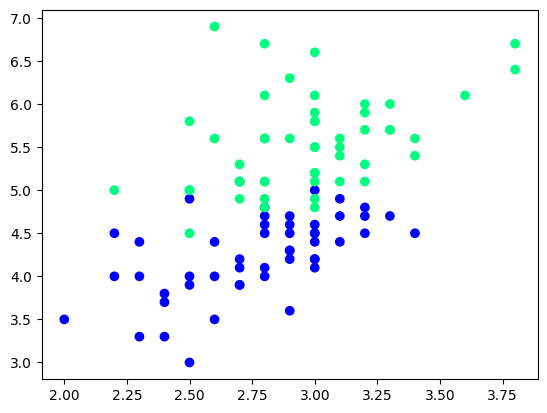

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [12]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
98,2.5,3.0,1
108,2.5,5.8,2
109,3.6,6.1,2
76,2.8,4.8,1
82,2.7,3.9,1
85,3.4,4.5,1
74,2.9,4.3,1
75,3.0,4.4,1
71,2.8,4.0,1
95,3.0,4.2,1


In [20]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)



X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

### #Case 1 - Bagging

In [21]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

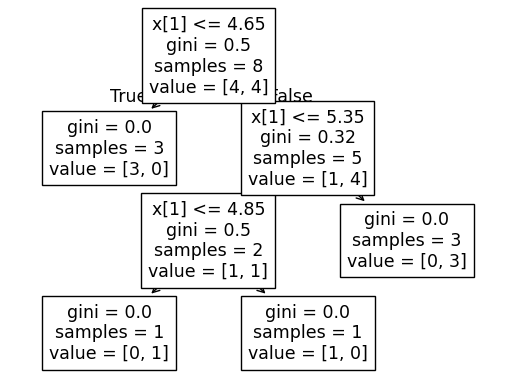

0.6


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


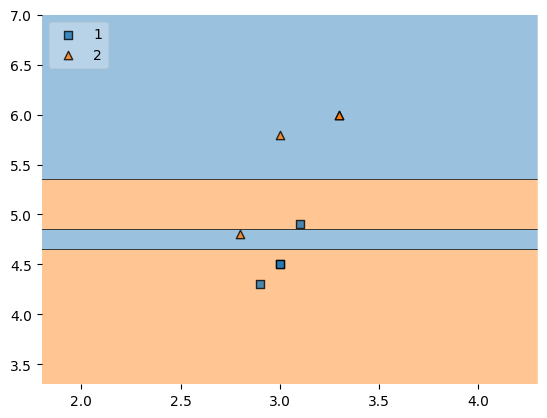

In [22]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag


from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score
dt_bag1 = DecisionTreeClassifier()
evaluate(dt_bag1,X,y)  # call above evalvate function

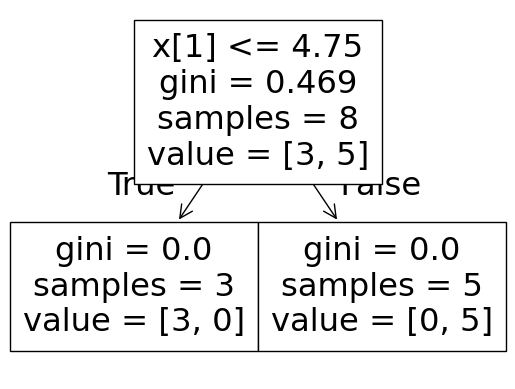

1.0


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


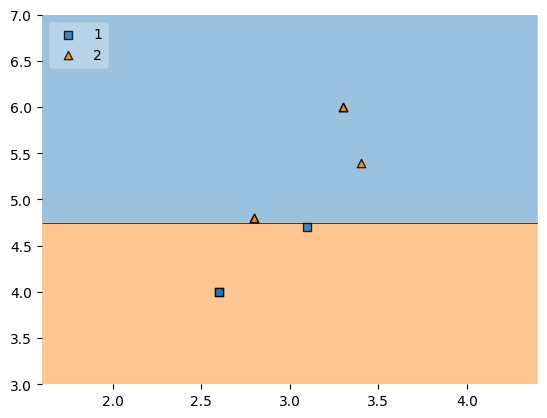

In [23]:
# Data for Tree 2
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag


dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

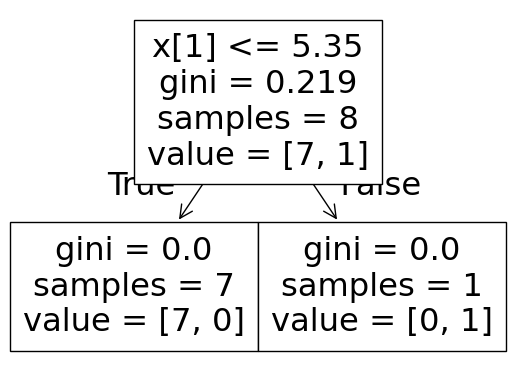

0.6


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


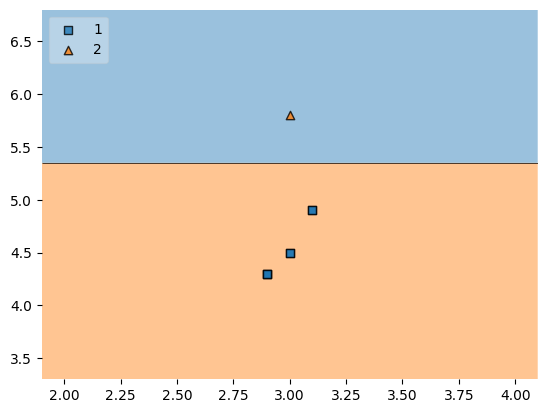

In [24]:
# Data for Tree 3
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)